# Bank Marketing Dataset - Decision Tree Classifier

## SkillCraft Technology Data Science Internship - Task 3

### Objective

Build a Decision Tree Classifier to predict whether a customer will subscribe to a term deposit based on demographic and behavioral attributes.

# Importing Essential Libraries

In [37]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
%matplotlib inline
import matplotlib.patches as mpatches
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_predict,cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler,LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2, f_classif,RFE

from sklearn.tree import DecisionTreeClassifier,plot_tree

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score,roc_curve, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)

# Loading Dataset

In [3]:
df=pd.read_csv("bank-full.csv",sep=";")
print("shape:",df.shape)
df.head()

shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# Basic Data Understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


# Exploring Categorical Features

In [7]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


job:
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

marital:
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

education:
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

default:
default
no     44396
yes      815
Name: count, dtype: int64

housing:
housing
yes    25130
no     20081
Name: count, dtype: int64

loan:
loan
no     37967
yes     7244
Name: count, dtype: int64

contact:
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

month:
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Nam

# Checking Duplicates & Missing Values

In [9]:
print("Duplicate rows:",df.duplicated().sum())
print("\nNul Values:")
print(df.isnull().sum())

Duplicate rows: 0

Nul Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


# Feature Engineering

In [12]:
df['was_previously_contacted']=(df['pdays'] != -1).astype(int)
print('previously contacted:',df['was_previously_contacted'].value_counts().to_dict())

df['pdays'] = df['pdays'].replace(-1,0)
print('pdays negative values after fix:',(df['pdays'] < 0).sum())

previously contacted: {0: 36954, 1: 8257}
pdays negative values after fix: 0


# Handling Data Issues

In [13]:
neg_balance = (df['balance'] < 0).sum()
print(f'Negative balance rows: {neg_balance} -> keeping as-is (overdrawn accounts are real)')

Negative balance rows: 3766 -> keeping as-is (overdrawn accounts are real)


# Handling 'Unknown' Values

In [16]:
cat_cols = df.select_dtypes(include=['object','category']).columns
for col in cat_cols:
    unk = (df[col] == 'unknown').sum()
    if unk > 0:
        pct = round( unk/ len(df) * 100,1)
        print(f'{col:12s}: {unk:5d} unknowns ({pct}%)')

job         :   288 unknowns (0.6%)
education   :  1857 unknowns (4.1%)
contact     : 13020 unknowns (28.8%)
poutcome    : 36959 unknowns (81.7%)


# Data Cleaning

In [17]:
job_mode = df[df['job'] != 'unknown']['job'].mode()[0]
df['job'] = df['job'].replace('unknown', job_mode)
print(f'job mode used: {job_mode}  | remaining unknowns: {(df["job"]=="unknown").sum()}')

edu_mode = df[df['education'] != 'unknown']['education'].mode()[0]
df['education'] = df['education'].replace('unknown', edu_mode)
print(f'education mode used: {edu_mode}  | remaining unknowns: {(df["education"]=="unknown").sum()}')

print('contact & poutcome unknowns kept as a valid category.')

job mode used: blue-collar  | remaining unknowns: 0
education mode used: secondary  | remaining unknowns: 0
contact & poutcome unknowns kept as a valid category.


# Outlier Treatment (IQR Method)

In [18]:
def cap_iqr(df,col):
    Q1, Q3= df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n= df[(df[col]<lower) | (df[col] > upper)].shape[0]
    df[col] = df[col].clip(lower,upper)
    print(f" {col:12s} [{lower:8.1f},{upper:8.1f}] | {n} capped") 
    return df

print("capping outliers...\n") 
for col in ["age","balance","duration" ,"campaign"]:
    df = cap_iqr(df, col)


capping outliers...

 age          [    10.5,    70.5] | 487 capped
 balance      [ -1962.0,  3462.0] | 4729 capped
 duration     [  -221.0,   643.0] | 3235 capped
 campaign     [    -2.0,     6.0] | 3064 capped


# Final Cleaning of 'Unknown'

In [19]:
for col in df.select_dtypes(include="object").columns:
    u = (df[col] =="unknown").sum()
    if u>0:
        print( f" {col:12s}:  {u} ({u/len(df)*100:.1f}%)")

 contact     :  13020 (28.8%)
 poutcome    :  36959 (81.7%)


# Encoding Month Column

In [20]:
month_order = {'jan':1 ,'feb':2 ,'mar':3 ,'apr':4,'may':5,'jun':6,
               'jul':7 ,'aug':8 , 'sep':9,'oct':10, 'nov':11,'dec':12}
df['month_num'] = df['month'].map(month_order)

df['age_group']= pd.cut(df['age'],
                        bins=[17,29,39,49,59,100],
                        labels=['18-29','30-39','40-49','50-59','60+'])

df['balance_tier']= pd.cut(df['balance'],
                           bins=[-np.inf,0,500,2000,np.inf],
                           labels=['Negative','Low','Medium','High'])

print('New features added: month_num , age_group, balance_tier, was_previously_contacted')
print(df[['age_group','balance_tier','month_num', 'was_previously_contacted']].head())

New features added: month_num , age_group, balance_tier, was_previously_contacted
  age_group balance_tier  month_num  was_previously_contacted
0     50-59         High          5                         0
1     40-49          Low          5                         0
2     30-39          Low          5                         0
3     40-49       Medium          5                         0
4     30-39          Low          5                         0


# Exploratory Data Analysis (EDA)

## Target Variable Distribution(y)

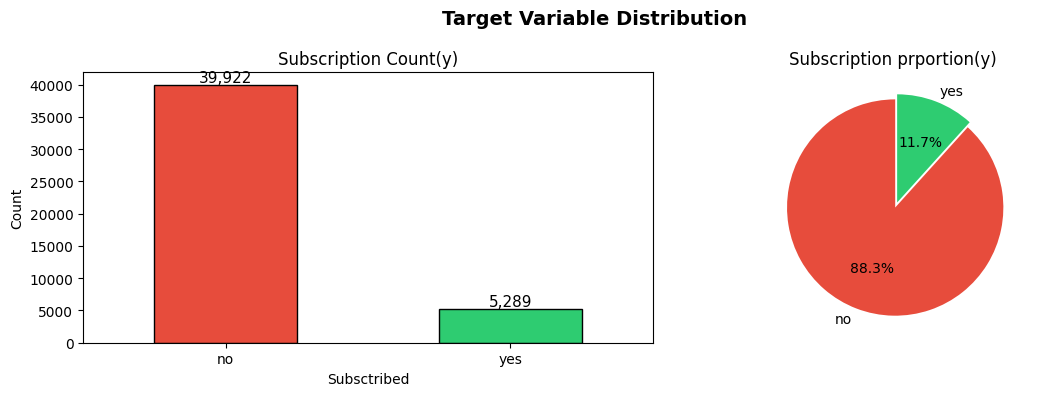

class Distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Class ratio(%):
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


In [22]:
fig , axes = plt.subplots(1, 2, figsize=(12,4))

df['y'].value_counts().plot(kind='bar', ax=axes[0],
                                color=['#e74c3c','#2ecc71'],
                            edgecolor='black')
axes[0].set_title('Subscription Count(y)')
axes[0].set_xlabel('Subsctribed') 
axes[0].set_ylabel('Count') 
axes[0].tick_params(axis='x',rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center',va='bottom',fontsize=11)

df['y'].value_counts().plot(kind='pie',ax=axes[1],
                                autopct='%1.1f%%',startangle=90,
                                colors=['#e74c3c','#2ecc71'],
                                explode=[0,0.05])
axes[1].set_title('Subscription prportion(y) ')
axes[1].set_ylabel('')

plt.suptitle('Target Variable Distribution',fontsize=14,fontweight='bold') 
plt.tight_layout()
plt.show()

print('class Distribution:') 
print(df['y'].value_counts())
print('\nClass ratio(%):')
print(df['y'].value_counts(normalize=True).mul(100).round(1))

# Histogram - All Numerical Columns

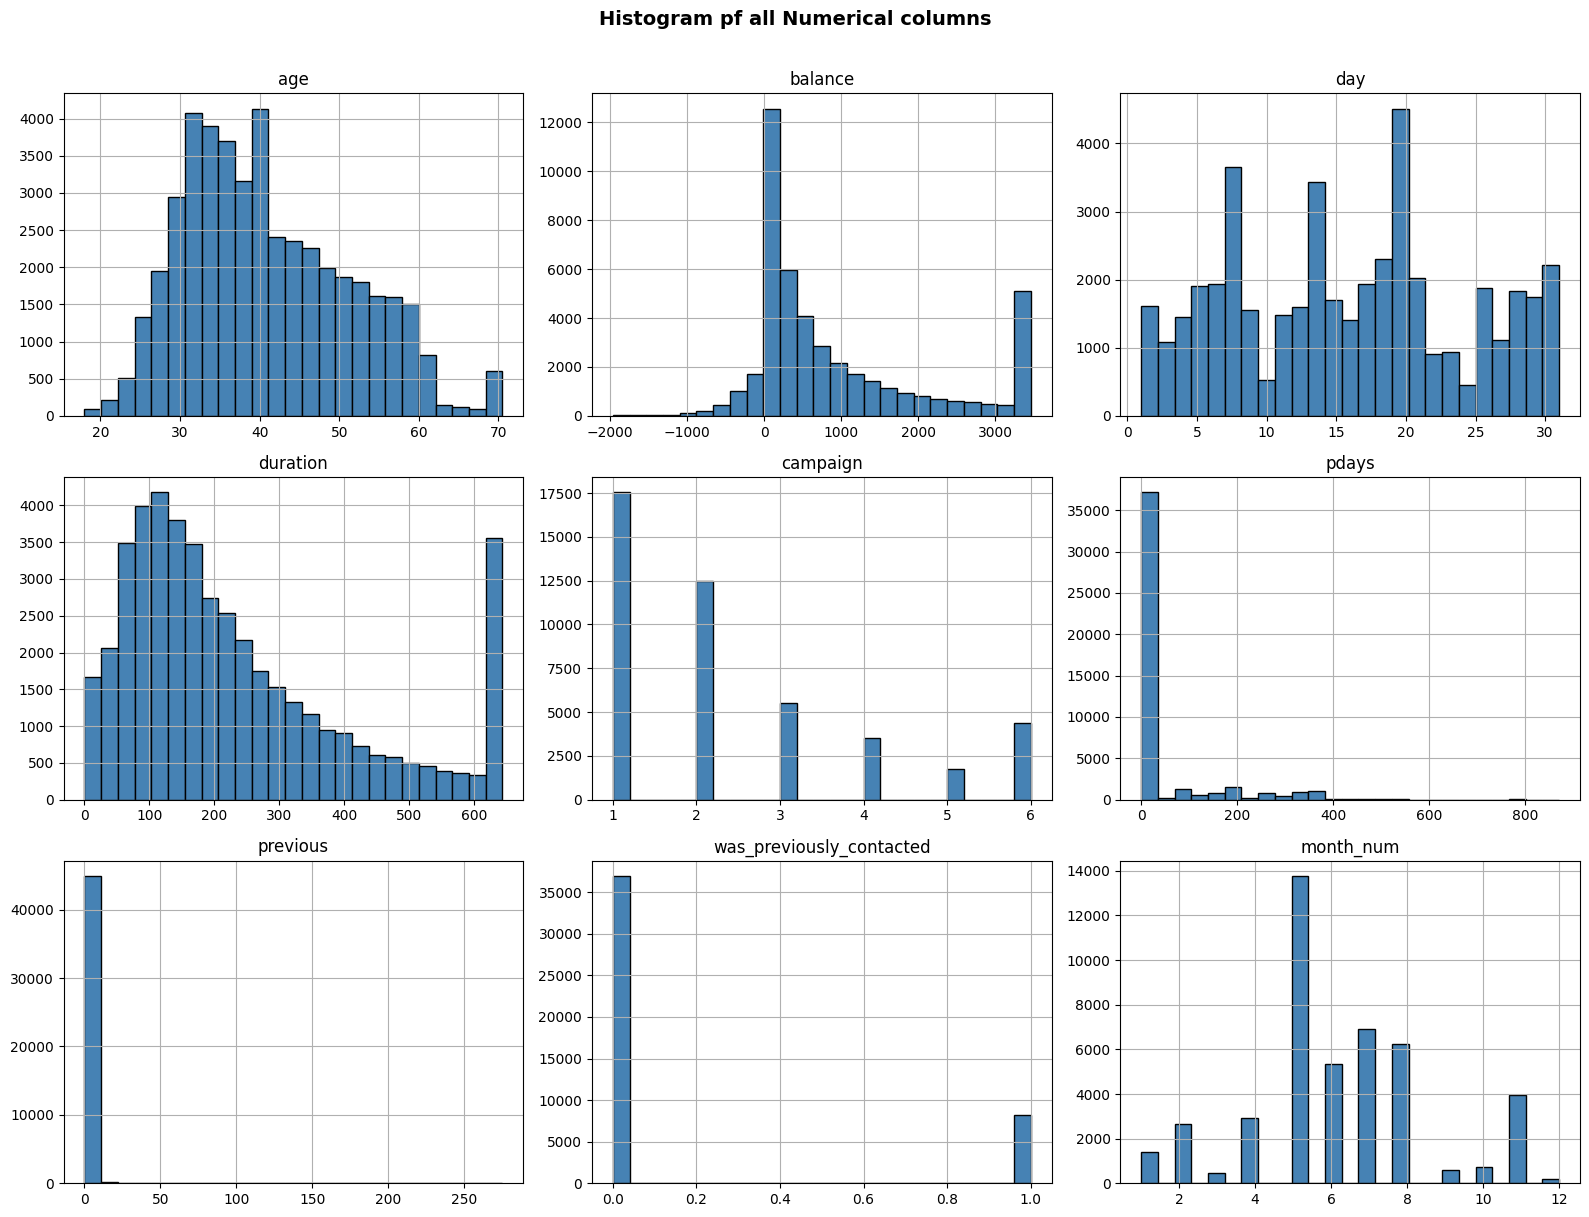

In [23]:
df.hist(bins=25,figsize=(16,12),edgecolor='black' ,color='steelblue') 
plt.suptitle('Histogram pf all Numerical columns',fontsize=14, fontweight='bold',y=1.01)
plt.tight_layout()
plt.show()

# Balance Analysis

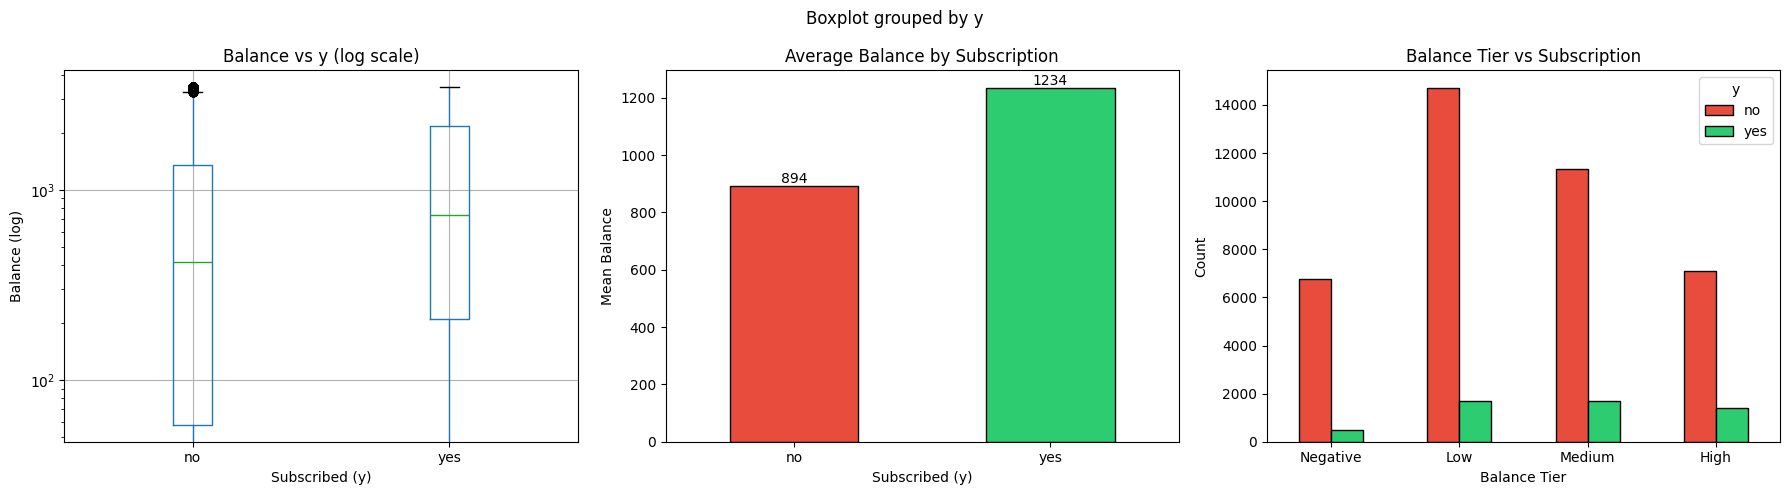

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df.boxplot(column='balance', by='y', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Balance vs y (log scale)')
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('Balance (log)')
plt.sca(axes[0]); plt.title('Balance vs y (log scale)')

df.groupby('y')['balance'].mean().plot(
    kind='bar', ax=axes[1],
    color=['#e74c3c','#2ecc71'], edgecolor='black'
)
axes[1].set_title('Average Balance by Subscription')
axes[1].set_xlabel('Subscribed (y)')
axes[1].set_ylabel('Mean Balance')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.0f}',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

df.groupby(['balance_tier','y']).size().unstack().plot(
    kind='bar', ax=axes[2],
    color=['#e74c3c','#2ecc71'], edgecolor='black'
)
axes[2].set_title('Balance Tier vs Subscription')
axes[2].set_xlabel('Balance Tier')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='y')

plt.tight_layout()
plt.show()

# Monthly Subscription Trend(Line Plot)

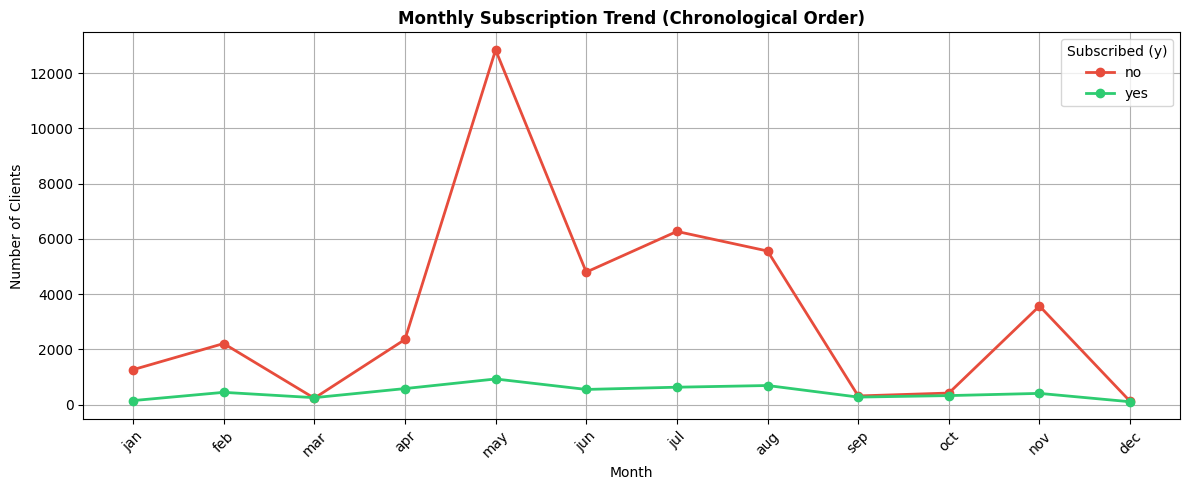

In [25]:
month_data = (
    df.groupby(['month_num', 'month', 'y'])
      .size()
      .reset_index(name='count')
      .sort_values('month_num')
)

pivot = month_data.pivot_table(index=['month_num','month'], columns='y', values='count').reset_index()
pivot.index = pivot['month']  

fig, ax = plt.subplots(figsize=(12, 5))
pivot[['no','yes']].plot(
    kind='line', ax=ax,
    marker='o', color=['#e74c3c','#2ecc71'],
    linewidth=2, markersize=6, grid=True
)
ax.set_xticks(range(len(pivot)))
ax.set_xticklabels(pivot['month'].tolist(), rotation=45)
ax.set_title('Monthly Subscription Trend (Chronological Order)', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Clients')
ax.legend(title='Subscribed (y)')
plt.tight_layout()
plt.show()

# Correlation Heatmap

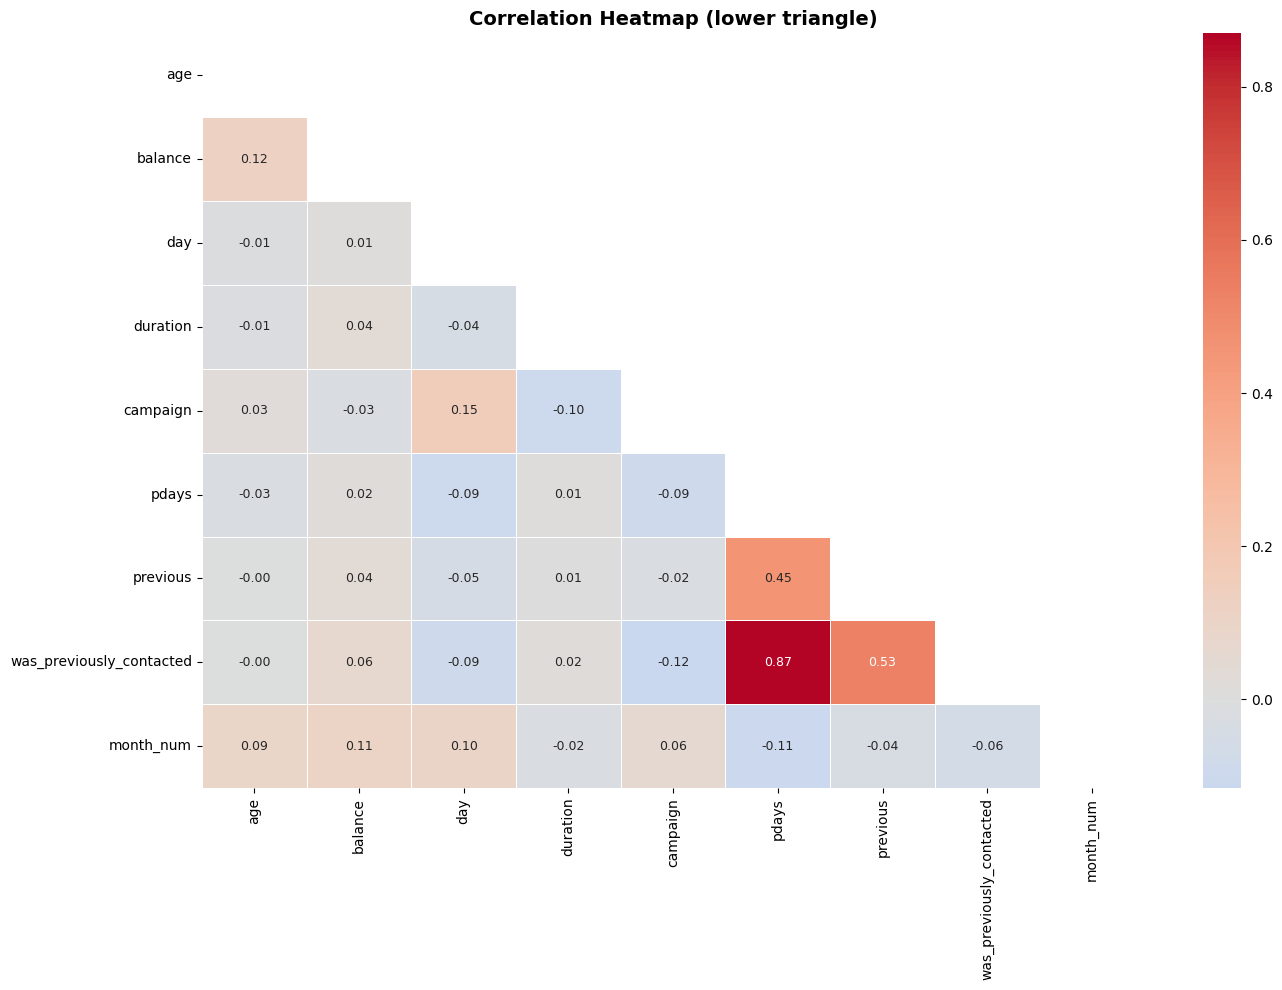

In [26]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool)) 
sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    mask=mask,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}
)
plt.title('Correlation Heatmap (lower triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature Selection

In [28]:
drop_cols = [
    'duration',
    'month',
    'age_group',
    'balance_tier',
    'balance',
    'campaign',
    'previous',
    'pdays'
]
df_model = df.drop(columns=drop_cols)
print('Shape after dropping redundant columns:', df_model.shape)
print('\nRemaining columns:') 
print(df_model.columns.tolist())

Shape after dropping redundant columns: (45211, 13)

Remaining columns:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'day', 'poutcome', 'y', 'was_previously_contacted', 'month_num']


# Encoding

In [29]:
df_enc = df_model.copy()

binary_cols = ['default', 'housing', 'loan']
for col in binary_cols:
    df_enc[col] = df_enc[col].map({'yes': 1, 'no': 0})
print('Binary encoding done:', binary_cols)

df_enc['y'] = df_enc['y'].map({'yes': 1, 'no': 0})
print('Target y encoded: no=0, yes=1') 
print('Class distribution after encoding:') 
print(df_enc['y'].value_counts())

ohe_cols = ['job', 'marital', 'education', 'contact', 'poutcome']
df_enc = pd.get_dummies(df_enc, columns=ohe_cols, drop_first=True, dtype=int)
print(f'\nShape after One-Hot Encoding: {df_enc.shape}') 
print('Null check:', df_enc.isnull().sum().sum(), 'nulls') 
df_enc.head(3)

Binary encoding done: ['default', 'housing', 'loan']
Target y encoded: no=0, yes=1
Class distribution after encoding:
y
0    39922
1     5289
Name: count, dtype: int64

Shape after One-Hot Encoding: (45211, 27)
Null check: 0 nulls


,age,default,housing,loan,day,y,was_previously_contacted,month_num,job_blue-collar,job_entrepreneur,...,job_unemployed,marital_married,marital_single,education_secondary,education_tertiary,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown
0,58.0,0,1,0,5,0,0,5,0,0,...,0,1,0,0,1,0,1,0,0,1
1,44.0,0,1,0,5,0,0,5,0,0,...,0,0,1,1,0,0,1,0,0,1
2,33.0,0,1,1,5,0,0,5,0,1,...,0,1,0,1,0,0,1,0,0,1


# Define Feature (X) and Target(Y)

In [30]:
X = df_enc.drop(columns=['y'])
y = df_enc['y']

print('Feature matrix X:', X.shape)
print('Target vector y:', y.shape)
print('\nClass balance:') 
print(y.value_counts())
print(f' -> Imbalance ratio: {y.value_counts()[0]/y.value_counts()[1]:.1f}:1 (no:yes)')

Feature matrix X: (45211, 26)
Target vector y: (45211,)

Class balance:
y
0    39922
1     5289
Name: count, dtype: int64
 -> Imbalance ratio: 7.5:1 (no:yes)


# SelectKBest - Statistical Feature Scores

Top 15 features by F-score:
                 Feature     F_Score       P_Value
        poutcome_success 4697.113837  0.000000e+00
was_previously_contacted 1301.219109 6.086689e-281
        poutcome_unknown 1297.815887 3.186284e-280
         contact_unknown 1053.932776 1.456834e-228
                 housing  892.950576 2.621927e-194
             job_retired  285.698413  6.767486e-64
             job_student  268.917823  2.917711e-60
         job_blue-collar  230.863951  5.195184e-52
                    loan  211.167395  9.793658e-48
      education_tertiary  200.499806  2.032274e-45
          marital_single  183.181227  1.180612e-41
         marital_married  164.766391  1.197208e-37
          job_management   49.043706  2.538079e-12
          poutcome_other   46.211124  1.074872e-11
     education_secondary   45.701836  1.393619e-11


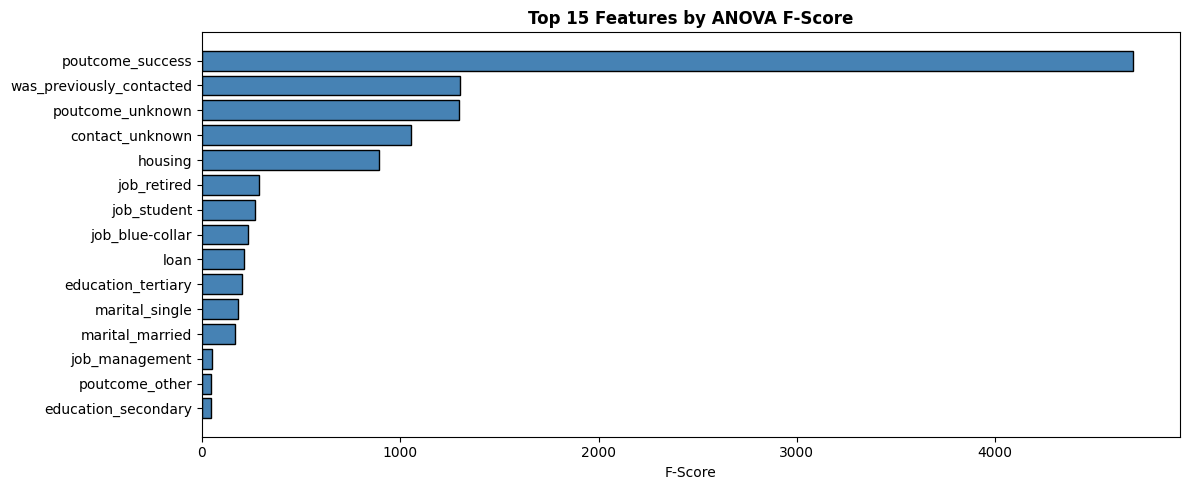

In [33]:
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

feat_scores = pd.DataFrame({
    'Feature': X.columns,
    'F_Score': selector.scores_,
    'P_Value': selector.pvalues_
}).sort_values('F_Score', ascending=False)

print('Top 15 features by F-score:')
print(feat_scores.head(15).to_string(index=False))

plt.figure(figsize=(12, 5))
top15 = feat_scores.head(15)
plt.barh(top15['Feature'][::-1], top15['F_Score'][::-1], color='steelblue', edgecolor='black')
plt.xlabel('F-Score')
plt.title('Top 15 Features by ANOVA F-Score', fontweight='bold')
plt.tight_layout()
plt.show()

# Feature Scaling

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}') 
print(f'Train Class balance: {y_train.value_counts().to_dict()}')
print(f'Test class balance: {y_test.value_counts().to_dict()}')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('StandardScaler applied.')
print(f'Train mean (first 3 cols): {X_train_scaled[:,:3].mean(axis=0).round(4)}')
print(f'Train std (first 3 cols): {X_train_scaled[:,:3].std(axis=0).round(4)}')

Train: (36168, 26) | Test: (9043, 26)
Train Class balance: {0: 31937, 1: 4231}
Test class balance: {0: 7985, 1: 1058}
StandardScaler applied.
Train mean (first 3 cols): [0. 0. 0.]
Train std (first 3 cols): [1. 1. 1.]


# Model Fitting

## Decision Tree Classifier

A Decision Tree Classifier was used to predict whether a customer would subscribe to a term deposit. The model learns decision rules from the training data by splitting observations based on feature values. 

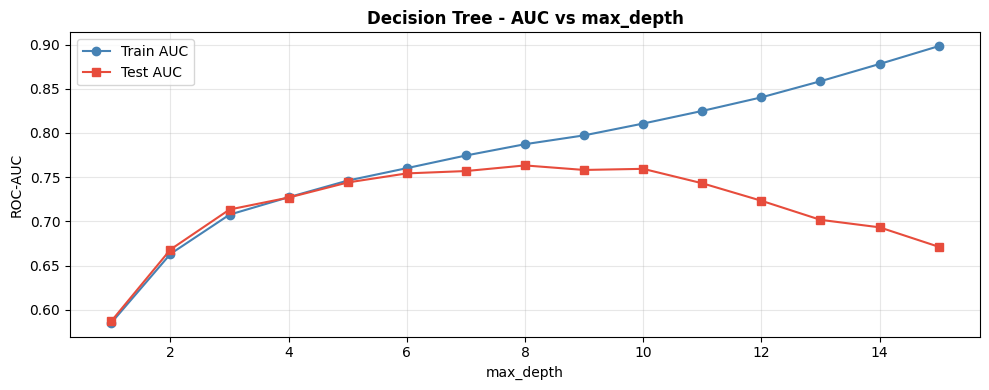

Best max_depth = 8 with test AUC = 0.7633


In [35]:
depth_range = range(1, 16)
train_auc_list, test_auc_list = [], []

for d in depth_range:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
    dt.fit(X_train_scaled, y_train)
    train_auc_list.append(roc_auc_score(y_train, dt.predict_proba(X_train_scaled)[:,1]))
    test_auc_list.append(roc_auc_score(y_test,       dt.predict_proba(X_test_scaled)[:,1]))

plt.figure(figsize=(10, 4))
plt.plot(depth_range, train_auc_list, 'o-', label='Train AUC', color='steelblue')
plt.plot(depth_range, test_auc_list,  's-', label='Test AUC',  color='#e74c3c')
plt.xlabel('max_depth')
plt.ylabel('ROC-AUC')
plt.title('Decision Tree - AUC vs max_depth', fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

best_depth = depth_range[test_auc_list.index(max(test_auc_list))]
print(f'Best max_depth = {best_depth} with test AUC = {max(test_auc_list):.4f}')

In [36]:
model = DecisionTreeClassifier(
    max_depth=best_depth,
    criterion='gini',
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train_scaled, y_train)
print('Decision Tree trained.')

Decision Tree trained.


In [38]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

acc_dt   = accuracy_score(y_test, y_pred)
y_pred_dt = y_pred.copy()
cv_dt    = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='roc_auc').mean()

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['No','Yes']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

          No       0.94      0.85      0.89      7985
         Yes       0.34      0.57      0.43      1058

    accuracy                           0.82      9043
   macro avg       0.64      0.71      0.66      9043
weighted avg       0.87      0.82      0.84      9043

ROC-AUC Score: 0.7699


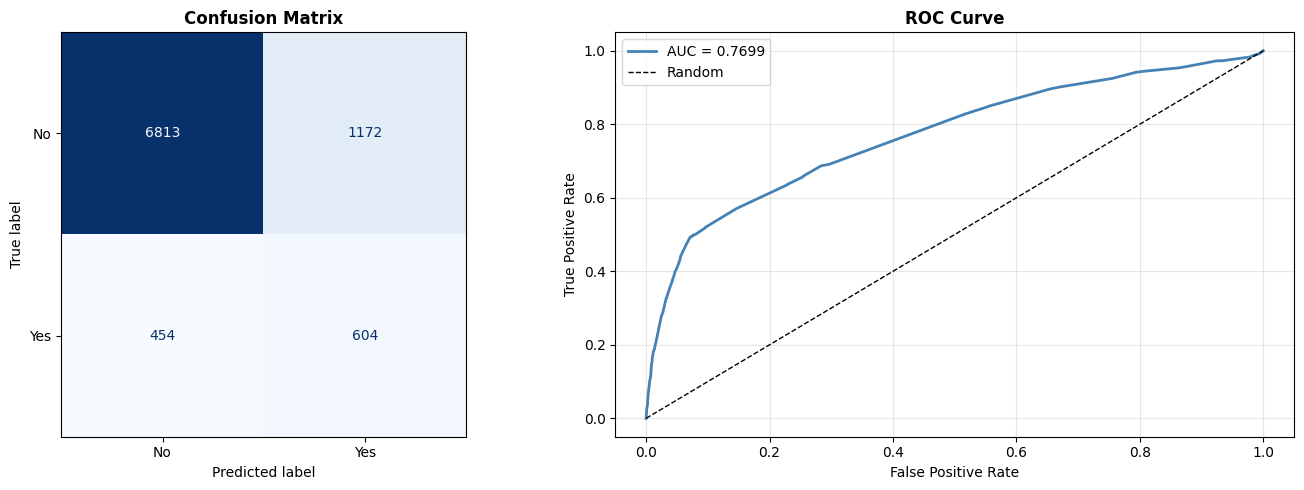

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No','Yes']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_title('ROC Curve', fontweight='bold')

plt.tight_layout(); plt.show()

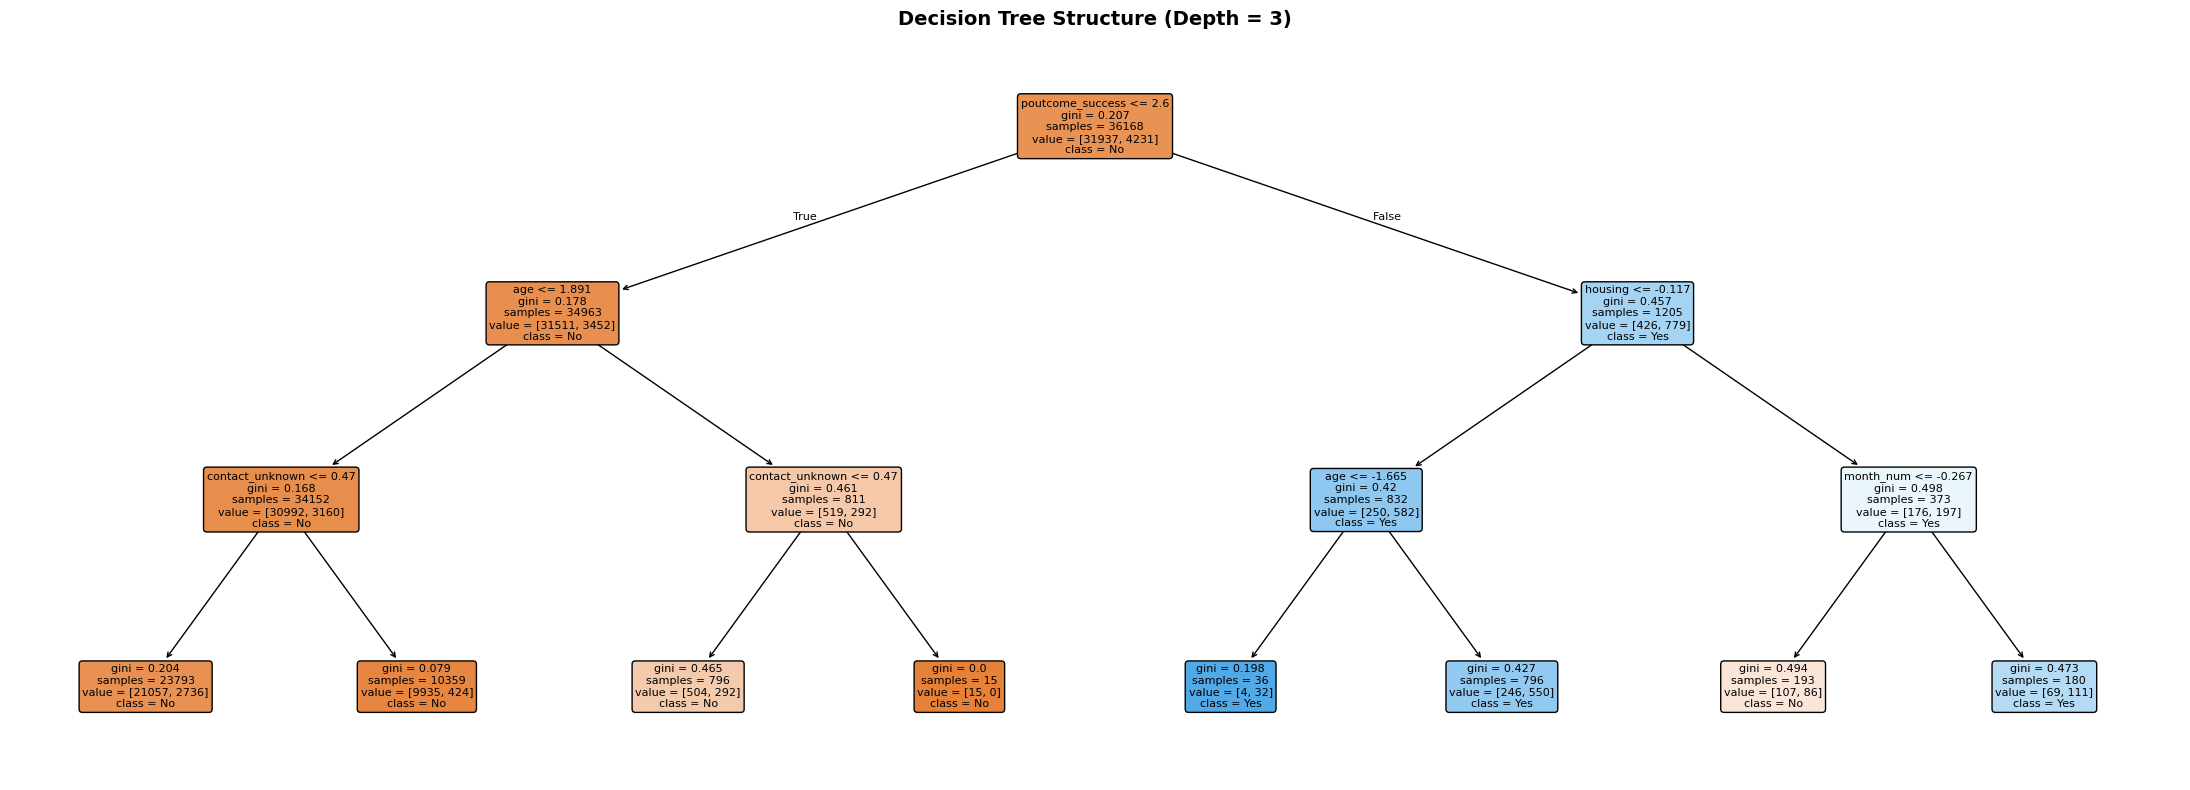

In [41]:
dt_vis = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_vis.fit(X_train_scaled, y_train)

feature_names = X_train.columns.tolist()
class_names   = ['No', 'Yes']

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt_vis,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
ax.set_title('Decision Tree Structure (Depth = 3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [42]:
print('Decision Tree Test Accuracy:', acc_dt)

Decision Tree Test Accuracy: 0.8201924140218954


## Conclusion

A Decision Tree Classifier was developed using the Bank Marketing dataset to predict whether a customer would subscribe to a term deposit. The workflow included data preprocessing, feature engineering, exploratory data analysis, feature selection, model training, and evaluation.

The model successfully identified patterns within customer demographic and behavioral data and produced reliable predictions. Evaluation metrics and visualizations were used to assess model performance and interpret the decision-making process of the classifier.
